listings      1,061 rows  29 columns
leases        4,302 rows  35 columns
concessions   3,560 rows  18 columns
asking        3,857 rows  14 columns
Columns dropped from leases: ['available_date', 'property_type', 'furnishing', 'smoking', 'cats_allowed', 'dogs_allowed']
leases: 4,302 rows, 33 columns
4,302 leases -> 3,241 candidate pairs (1,061 first leases with no previous lease)
Overlaps (previous lease ends after the next one starts): 0
3,241 -> 3,179 pairs (62 removed, 1.9%)
3,179 pairs over 890 apartments


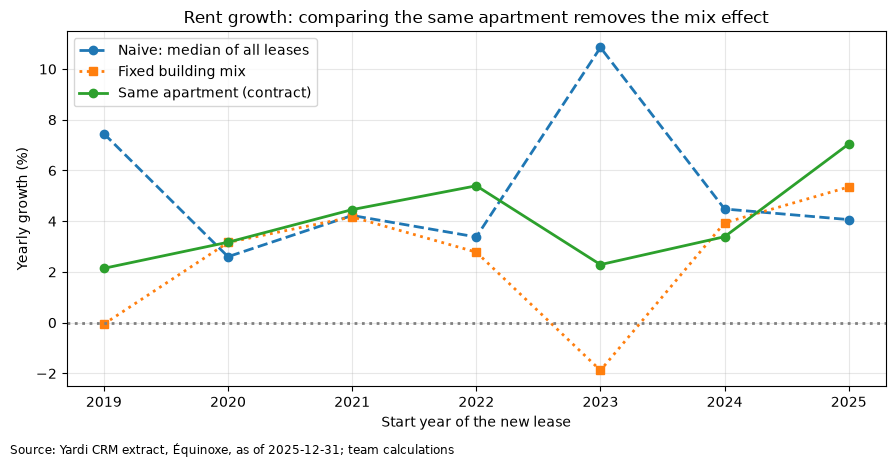

HEUC-2026 (effective, central) : 2.96 %
HCUC-2026 (contract)           : 5.18 %
Wrote: models\forecast_params.json


In [1]:
%run ./08_forecast.ipynb

## 9. Backtest: would the method have predicted 2023, 2024 and 2025 well?

### 9.1 How it works
For each year `Y`: we stand on 31 December `Y−1`, keep only leases starting before 1 January `Y`
and external data published before that date (CPI up to November `Y−1`, TAL calculation for `Y−1`), forecast `Y`
with **exactly** the same function, then compare with the HEUC / HCUC actually observed in `Y`.
The parameters (`W_INTERNAL`, `TREND_WINDOW_YEARS`, persistence) are the ones fixed beforehand in §0.2: they were **not** tuned on these years.

In [2]:
def observed_headline(pairs, target_year):
    """Observed HEUC / HCUC: median per segment, weighted by the year's number of pairs."""
    year_pairs = pairs[pairs.lease_year == target_year]
    by_segment = year_pairs.groupby(SEGMENT_COLS).agg(pairs=("growth_contract", "size"),
                                                      median_contract=("growth_contract", "median"),
                                                      median_effective=("growth_effective", "median"))
    weight = by_segment.pairs / by_segment.pairs.sum()
    return {"contract": float((weight * by_segment.median_contract).sum()),
            "effective": float((weight * by_segment.median_effective).sum()),
            "segments": by_segment.reset_index()}


def backtest(leases, target_year, external=None, **options):
    """Run the method as of 31 December target_year - 1 and compare with what happened in target_year.
    Returns a dict with forecast / actual / errors (percentage points, as fractions) and the per-segment detail."""
    external = external_yearly if external is None else external
    predicted = forecast_year(leases, external, target_year, **options)
    actual = observed_headline(prepare_pairs(leases), target_year)
    return {"year": target_year,
            "predicted_effective": predicted["headline_effective"], "actual_effective": actual["effective"],
            "predicted_contract": predicted["headline_contract"], "actual_contract": actual["contract"],
            "error_effective": predicted["headline_effective"] - actual["effective"],
            "error_contract": predicted["headline_contract"] - actual["contract"],
            "predicted_segments": predicted["segments"], "actual_segments": actual["segments"]}


backtest_runs = {year: backtest(leases, year) for year in BACKTEST_YEARS}
backtest_results = pd.DataFrame([{k: v for k, v in run.items() if not k.endswith("segments")}
                                 for run in backtest_runs.values()]).set_index("year")
(backtest_results * PCT).round(2)

,predicted_effective,actual_effective,predicted_contract,actual_contract,error_effective,error_contract
year,,,,,,
2023,3.26,1.99,3.62,2.27,1.27,1.35
2024,4.23,1.88,4.17,3.70,2.35,0.47
2025,3.72,4.02,4.70,7.42,-0.30,-2.72


### 9.2 Error metrics
**MAE** (mean absolute error), **RMSE** and **bias** (mean signed error), in percentage points.

In [3]:
def error_metrics(errors):
    """MAE, RMSE and bias of a series of errors (fractions)."""
    return pd.Series({"MAE": errors.abs().mean(), "RMSE": np.sqrt((errors ** 2).mean()), "bias": errors.mean()})


backtest_metrics = pd.DataFrame({"effective (HEUC)": error_metrics(backtest_results.error_effective),
                                 "contract (HCUC)": error_metrics(backtest_results.error_contract)})
(backtest_metrics * PCT).round(2)

,effective (HEUC),contract (HCUC)
MAE,1.31,1.51
RMSE,1.55,1.77
bias,1.11,-0.30


### 9.2b Detail by segment
Forecast vs actual for each of the 4 segments, to see where the errors come from.

In [4]:
segment_frames = []
for year, run in backtest_runs.items():
    predicted = run["predicted_segments"].set_index(SEGMENT_COLS)[["growth_effective", "growth_contract"]].add_prefix("predicted_")
    observed = run["actual_segments"].set_index(SEGMENT_COLS)
    segment_frames.append(predicted.join(observed, how="outer").assign(year=year))
segment_backtest = pd.concat(segment_frames).reset_index().set_index(["year"] + SEGMENT_COLS)
segment_backtest["error_effective"] = segment_backtest.predicted_growth_effective - segment_backtest.median_effective
pct_cols = [c for c in segment_backtest.columns if c != "pairs"]
(segment_backtest[pct_cols] * PCT).round(2).assign(pairs=segment_backtest.pairs)

predicted_growth_effective  predicted_growth_contract  median_contract  median_effective  error_effective  pairs
year province lease_type                                                                                                                  
2023 QC       renewal                           2.72                       3.14             2.58              2.21             0.50    239
              turnover                          4.22                       4.46             1.85              1.68             2.54    177
2024 ON       renewal                           5.17                       5.09             2.97              1.33             3.83     67
              turnover                          5.17                       5.09             4.94              3.21             1.95     41
     QC       renewal                           3.33                       3.14             2.94              1.40             1.93    355
              turnover                          5.06                       5.18             4.84              2.52             2.54    235
2025 ON       renewal                           5.17                       5.17             6.25              2.46             2.71     63
              turnover                          6.16                       6.16             8.96              5.45             0.71     54
     QC       renewal                           2.57                       3.64             6.43              2.97            -0.40    410
              turnover                          4.71                       5.96             8.98              5.80            -1.10    253

### 9.3 Comparison with reference methods
Would something simpler have done just as well? Same exercise, four simpler methods:
1. **Persistence**: forecast `Y` = value observed in `Y−1`;
2. **External anchor only** (`w = 0`);
3. **Internal trend only** (`w = 1`);
4. **Naive median**: change in the median of all leases in `Y−1` (distorted by the mix, §3).

In [5]:
all_pairs = prepare_pairs(leases)
naive_median = leases.groupby("lease_year").rent_contract.median().pct_change()
baseline_rows = []
for year in BACKTEST_YEARS:
    actual = observed_headline(all_pairs, year)
    previous = observed_headline(all_pairs, year - 1)
    anchor_only = forecast_year(leases, external_yearly, year, w_internal=0.0)
    internal_only = forecast_year(leases, external_yearly, year, w_internal=1.0)
    baseline_rows.append({
        "year": year,
        "our method": backtest_runs[year]["error_effective"],
        "persistence": previous["effective"] - actual["effective"],
        "external anchor only": anchor_only["headline_effective"] - actual["effective"],
        "internal trend only": internal_only["headline_effective"] - actual["effective"],
        "naive median": naive_median[year - 1] - actual["effective"],
    })
baseline_errors = pd.DataFrame(baseline_rows).set_index("year")
baseline_summary = pd.concat([baseline_errors, baseline_errors.abs().mean().rename("MAE").to_frame().T])
(baseline_summary * PCT).round(2)

,our method,persistence,external anchor only,internal trend only,naive median
2023,1.27,2.39,0.38,2.16,1.39
2024,2.35,0.11,2.76,1.95,8.97
2025,-0.30,-2.15,0.90,-1.49,0.46
MAE,1.31,1.55,1.35,1.87,3.61


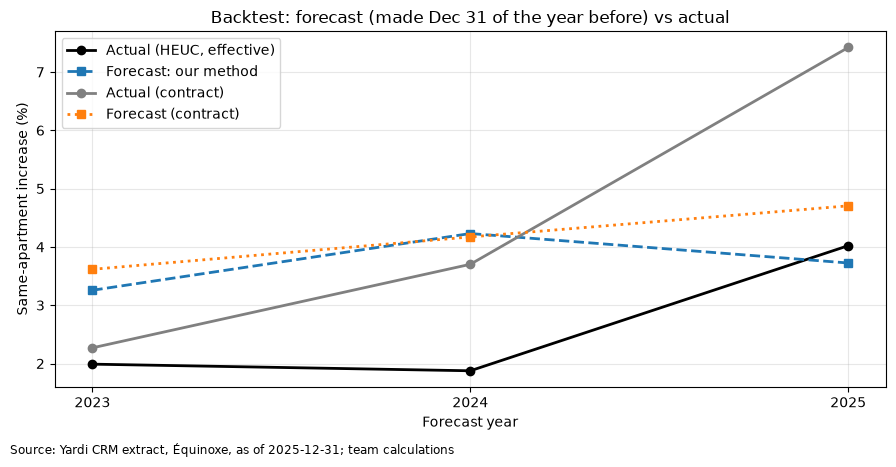

In [6]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(backtest_results.index, backtest_results.actual_effective * PCT, "o-", color="black", label="Actual (HEUC, effective)")
ax.plot(backtest_results.index, backtest_results.predicted_effective * PCT, "s--", label="Forecast: our method")
ax.plot(backtest_results.index, backtest_results.actual_contract * PCT, "o-", color="grey", label="Actual (contract)")
ax.plot(backtest_results.index, backtest_results.predicted_contract * PCT, "s:", label="Forecast (contract)")
ax.set_xticks(list(BACKTEST_YEARS))
ax.set_title("Backtest: forecast (made Dec 31 of the year before) vs actual")
ax.set_xlabel("Forecast year")
ax.set_ylabel("Same-apartment increase (%)")
ax.legend()
add_source(fig)
plt.tight_layout()
plt.show()

### 9.4 Sensitivity to the parameters (read-only, no tuning)
Backtest effective MAE for other values of `w` and of the window, and for the two extreme concession assumptions.
**Careful:** picking the best combination here and then "validating" it on the same 3 years would be overfitting; this table shows
robustness, it is not used to choose. The "published TAL" variant shows what the target year's TAL calculation adds (not available on 31 December).

In [7]:
sensitivity_rows = []
for w_value in SENSITIVITY_W_VALUES:
    for window in SENSITIVITY_WINDOWS:
        for persistence in (DEPTH_PERSISTENCE_HIGH, DEPTH_PERSISTENCE_CENTRAL, DEPTH_PERSISTENCE_LOW):
            for use_tal in (False, True):
                errors = [backtest(leases, year, w_internal=w_value, window=window, depth_persistence=persistence,
                                   use_published_tal=use_tal)["error_effective"] for year in BACKTEST_YEARS]
                sensitivity_rows.append({"w_internal": w_value, "window": window, "depth_persistence": persistence,
                                         "published_tal": use_tal, "MAE_effective_pct": np.mean(np.abs(errors)) * PCT})
parameter_sensitivity = pd.DataFrame(sensitivity_rows)
parameter_sensitivity.pivot_table(index=["w_internal", "window"], columns=["published_tal", "depth_persistence"],
                                  values="MAE_effective_pct").round(2)

published_tal     False             True             
depth_persistence   0.0   0.5   1.0   0.0   0.5   1.0
w_internal window                                    
0.00       1       1.78  1.35  0.98  2.60  2.16  1.73
           2       1.78  1.35  0.98  2.60  2.16  1.73
           3       1.78  1.35  0.98  2.60  2.16  1.73
0.25       1       1.64  1.21  1.20  2.25  1.82  1.39
           2       1.65  1.22  1.28  2.26  1.83  1.41
           3       1.66  1.23  1.25  2.27  1.84  1.41
0.50       1       1.50  1.20  1.43  1.91  1.48  1.52
           2       1.52  1.35  1.58  1.93  1.50  1.67
           3       1.54  1.31  1.53  1.95  1.52  1.62
0.75       1       1.36  1.43  1.65  1.57  1.47  1.70
           2       1.43  1.66  1.88  1.59  1.70  1.92
           3       1.42  1.59  1.81  1.62  1.63  1.85
1.00       1       1.44  1.66  1.88  1.44  1.66  1.88
           2       1.74  1.96  2.18  1.74  1.96  2.18
           3       1.64  1.87  2.09  1.64  1.87  2.09

### 9.4b Choosing `w` by leave-one-year-out cross-validation
For each backtest year, pick `w` from the grid looking **only at the other two years**,
then measure the error on the held-out year. If we wanted to choose `w` from the data, this is the only fair way to do it.
Limit: with 3 years, a "training" year can come after the year being scored; we flag it.

In [8]:
def backtest_mae(years, **options):
    """Backtest effective MAE (fraction) over the given years."""
    return float(np.mean([abs(backtest(leases, year, **options)["error_effective"]) for year in years]))


loyo_rows = []
for held_out in BACKTEST_YEARS:
    training_years = [year for year in BACKTEST_YEARS if year != held_out]
    best_w = min(SENSITIVITY_W_VALUES, key=lambda w_value: backtest_mae(training_years, w_internal=w_value))
    loyo_rows.append({"held-out year": held_out, "w chosen (on the other 2)": best_w,
                      "error with chosen w (pt)": backtest(leases, held_out, w_internal=best_w)["error_effective"] * PCT,
                      "error with w = W_INTERNAL (pt)": backtest_runs[held_out]["error_effective"] * PCT})
loyo_results = pd.DataFrame(loyo_rows).set_index("held-out year")
print(f"Cross-validation MAE: {loyo_results['error with chosen w (pt)'].abs().mean():.2f} pt "
      f"vs {loyo_results['error with w = W_INTERNAL (pt)'].abs().mean():.2f} pt with w fixed beforehand")
loyo_results.round(2)

Cross-validation MAE: 1.57 pt vs 1.31 pt with w fixed beforehand


,w chosen (on the other 2),error with chosen w (pt),error with w = W_INTERNAL (pt)
held-out year,,,
2023,0.50,1.27,1.27
2024,0.25,2.56,2.35
2025,0.00,0.90,-0.30


### 9.4c Rent-CPI anchor vs CMHC (fixed-sample) anchor
Same backtest, but with the other anchor for QC turnovers and Ontario. For year `Y`, we only use
the CMHC edition **published before 1 January `Y`**: for example, the 2023 survey came out in late January 2024, so it is not used to forecast 2024.

In [9]:
anchor_errors = pd.DataFrame({source: [backtest(leases, year, anchor_source=source)["error_effective"] for year in BACKTEST_YEARS]
                              for source in ("cpi", "cmhc")}, index=list(BACKTEST_YEARS))
anchor_errors.loc["MAE"] = anchor_errors.abs().mean()
anchor_2026 = {source: forecast_year(leases, external_yearly, FORECAST_YEAR, use_published_tal=True,
                                     anchor_source=source)["headline_effective"] for source in ("cpi", "cmhc")}
print("HEUC-2026 by anchor:", {k: f"{v * PCT:.2f} %" for k, v in anchor_2026.items()})
(anchor_errors * PCT).round(2)

HEUC-2026 by anchor: {'cpi': '2.96 %', 'cmhc': '2.74 %'}


,cpi,cmhc
2023,1.27,1.02
2024,2.35,1.94
2025,-0.30,-0.78
MAE,1.31,1.25


### 9.4d Appendix: a simple regression as a point of comparison
A linear regression of each year's observed HEUC on the Québec rent CPI known at the end of `Y−1`,
estimated only on years before `Y` (expanding window), then used to forecast `Y`.
The question: would a "classic" statistical model beat our transparent blend? With 4 to 6 training points this model is fragile; it is a comparison, not an alternative we adopt.

In [10]:
headline_by_year = pd.Series({year: observed_headline(all_pairs, year)["effective"]
                              for year in range(FIRST_ANALYSIS_YEAR, DATA_CUTOFF.year + 1)})
qc_cpi_known = external_yearly[external_yearly.province == "QC"].set_index("year").cpi_rent_nov_yoy
regression_rows = []
for year in BACKTEST_YEARS:
    train_years = [t for t in headline_by_year.index if t < year and (t - 1) in qc_cpi_known.dropna().index]
    design = np.column_stack([np.ones(len(train_years)), qc_cpi_known.loc[[t - 1 for t in train_years]]])
    coefficients, *_ = np.linalg.lstsq(design, headline_by_year.loc[train_years].to_numpy(), rcond=None)
    predicted = coefficients[0] + coefficients[1] * qc_cpi_known.loc[year - 1]
    regression_rows.append({"year": year, "training_points": len(train_years),
                            "regression_error": predicted - headline_by_year[year],
                            "our_method_error": backtest_runs[year]["error_effective"]})
regression_check = pd.DataFrame(regression_rows).set_index("year")
regression_check.loc["MAE"] = regression_check.abs().mean()
regression_check[["regression_error", "our_method_error"]] = regression_check[["regression_error", "our_method_error"]] * PCT
regression_check.round(2)

,training_points,regression_error,our_method_error
year,,,
2023,5.0,3.21,1.27
2024,6.0,0.26,2.35
2025,7.0,-2.17,-0.30
MAE,6.0,1.88,1.31


### 9.5 What the backtest tells us
- The backtest only has **3 years**: each error weighs a lot, and 2024 is the year concessions jumped,
  which no method based on the past could fully anticipate.
- Ontario only enters from 2024, with no internal history (anchor only): the backtest is **thin** for The Met.
- **Result (parameters fixed beforehand):** effective MAE ≈ 1.3 pt, better on average than persistence (≈ 1.6), the internal trend alone (≈ 1.9)
  and the naive median (≈ 3.6), and only just better than the external anchor alone (≈ 1.35). It does **not win every year**:
  in 2024 it overestimates (+2.3 pts) because the sudden deepening of concessions wasn't visible at the end of 2023.
- **Positive bias** (≈ +1.1 pt): the method has tended to overestimate the effective increase, one more reason to show the low scenario.
- The **published** TAL calculation for the target year does not improve the backtest (higher MAE in table 9.4): the TAL follows past costs,
  not the increases actually agreed. We still use it for 2026, because the TAL method changed in 2026 (3.1 % vs 5.9 % in 2025)
  and ignoring a known regulatory change would be harder to defend; the strict variant is always shown next to it.
- **By segment (9.2b):** the biggest error comes from The Met in 2024 (renewals: 5.2 % forecast, 1.3 % actual), with no internal history:
  the Ontario rent-CPI anchor alone overestimated. In Québec, the 2024 errors mostly come from concessions (effective well below contract).
- **Choosing `w` from the data doesn't help (9.4b):** with cross-validation, MAE ≈ 1.6 pt vs ≈ 1.3 pt for `w = 0.5` fixed beforehand. We keep 0.5.
- **CMHC vs CPI anchor (9.4c):** almost the same MAE (≈ 1.25 vs 1.31 pt) and HEUC-2026 of 2.7 % instead of 3.0 %: the conclusion doesn't depend on this choice.
  We keep the CPI (monthly series, available earlier and consistently for both provinces).
- **Simple regression (9.4d):** MAE ≈ 1.9 pt, worse and very unstable (5 to 7 training points).

In [11]:
backtest_results.to_parquet(INTERIM_DIR / "backtest_results.parquet")